In [420]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings 
warnings.filterwarnings('ignore')

In [421]:
df = pd.read_csv('athlete_events.csv')
region_df = pd.read_csv('noc_regions.csv')

In [422]:
df.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


# EDA

In [423]:
df.shape

(271116, 15)

In [424]:
df = df[df["Season"] == "Summer"]

In [425]:
df.shape

(222552, 15)

In [426]:
region_df.head()

,NOC,region,notes
0,AFG,Afghanistan,NaN
1,AHO,Curacao,Netherlands Antilles
2,ALB,Albania,NaN
3,ALG,Algeria,NaN
4,AND,Andorra,NaN


In [427]:
df = df.merge(region_df , on = "NOC" , how = "left")

In [428]:
df.head(2)

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN,China,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN,China,NaN


In [429]:
df.isnull().sum()

ID             0
Name           0
Sex            0
Age         9189
Height     51857
Weight     53854
Team           0
NOC            0
Games          0
Year           0
Season         0
City           0
Sport          0
Event          0
Medal     188464
region       370
notes     218151
dtype: int64

In [430]:
print(df.duplicated().sum())

1385


In [431]:
df =  df.drop_duplicates()

In [432]:
print(df.duplicated().sum())

0


In [383]:
print(df["Medal"].unique())

[nan 'Gold' 'Bronze' 'Silver']


In [22]:
pd.get_dummies(df["Medal"]).astype(int)

,Bronze,Gold,Silver
0,0,0,0
1,0,0,0
2,0,0,0
3,0,1,0
4,0,0,0
...,...,...,...
222547,0,0,0
222548,0,0,0
222549,0,0,0
222550,0,0,0


In [24]:
df = pd.concat([df ,pd.get_dummies(df["Medal"]).astype(int)] , axis = 1)

In [25]:
df.head(2)

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes,Bronze,Gold,Silver
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN,China,NaN,0,0,0
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN,China,NaN,0,0,0


In [26]:
df[(df["NOC"] == "IND") & (df["Medal"] == "Gold")]

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes,Bronze,Gold,Silver
4186,2699,Shaukat Ali,M,30.0,NaN,NaN,India,IND,1928 Summer,1928,Summer,Amsterdam,Hockey,Hockey Men's Hockey,Gold,India,NaN,0,1,0
4190,2703,Syed Mushtaq Ali,M,22.0,165.0,61.0,India,IND,1964 Summer,1964,Summer,Tokyo,Hockey,Hockey Men's Hockey,Gold,India,NaN,0,1,0
4460,2864,Richard James Allen,M,25.0,172.0,NaN,India,IND,1928 Summer,1928,Summer,Amsterdam,Hockey,Hockey Men's Hockey,Gold,India,NaN,0,1,0
4461,2864,Richard James Allen,M,30.0,172.0,NaN,India,IND,1932 Summer,1932,Summer,Los Angeles,Hockey,Hockey Men's Hockey,Gold,India,NaN,0,1,0
4462,2864,Richard James Allen,M,34.0,172.0,NaN,India,IND,1936 Summer,1936,Summer,Berlin,Hockey,Hockey Men's Hockey,Gold,India,NaN,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
191759,117232,Dung Dung Sylvanus,M,31.0,160.0,62.0,India,IND,1980 Summer,1980,Summer,Moskva,Hockey,Hockey Men's Hockey,Gold,India,NaN,0,1,0
193964,118553,Carlyle Carrol Tapsell,M,23.0,182.0,NaN,India,IND,1932 Summer,1932,Summer,Los Angeles,Hockey,Hockey Men's Hockey,Gold,India,NaN,0,1,0
193965,118553,Carlyle Carrol Tapsell,M,27.0,182.0,NaN,India,IND,1936 Summer,1936,Summer,Berlin,Hockey,Hockey Men's Hockey,Gold,India,NaN,0,1,0
205949,125560,"Max ""Maxie"" Vaz",M,NaN,NaN,NaN,India,IND,1948 Summer,1948,Summer,London,Hockey,Hockey Men's Hockey,Gold,India,NaN,0,1,0


# Medal Tally

In [32]:
medal_tally = df.drop_duplicates(subset = ['Team', 'region','NOC','Games', 'Season', 'City','Sport','Event','Medal'])

In [37]:
medal_tally[(medal_tally["NOC"] == "IND") & (medal_tally["Medal"] == "Gold")]

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes,Bronze,Gold,Silver
4186,2699,Shaukat Ali,M,30.0,NaN,NaN,India,IND,1928 Summer,1928,Summer,Amsterdam,Hockey,Hockey Men's Hockey,Gold,India,NaN,0,1,0
4190,2703,Syed Mushtaq Ali,M,22.0,165.0,61.0,India,IND,1964 Summer,1964,Summer,Tokyo,Hockey,Hockey Men's Hockey,Gold,India,NaN,0,1,0
4461,2864,Richard James Allen,M,30.0,172.0,NaN,India,IND,1932 Summer,1932,Summer,Los Angeles,Hockey,Hockey Men's Hockey,Gold,India,NaN,0,1,0
4462,2864,Richard James Allen,M,34.0,172.0,NaN,India,IND,1936 Summer,1936,Summer,Berlin,Hockey,Hockey Men's Hockey,Gold,India,NaN,0,1,0
17790,11197,Vasudevan Bhaskaran,M,29.0,174.0,68.0,India,IND,1980 Summer,1980,Summer,Moskva,Hockey,Hockey Men's Hockey,Gold,India,NaN,0,1,0
18444,11601,Abhinav Bindra,M,25.0,173.0,70.0,India,IND,2008 Summer,2008,Summer,Beijing,Shooting,"Shooting Men's Air Rifle, 10 metres",Gold,India,NaN,0,1,0
35545,21912,Leslie Walter Claudius,M,21.0,162.0,53.0,India,IND,1948 Summer,1948,Summer,London,Hockey,Hockey Men's Hockey,Gold,India,NaN,0,1,0
35546,21912,Leslie Walter Claudius,M,25.0,162.0,53.0,India,IND,1952 Summer,1952,Summer,Helsinki,Hockey,Hockey Men's Hockey,Gold,India,NaN,0,1,0
35547,21912,Leslie Walter Claudius,M,29.0,162.0,53.0,India,IND,1956 Summer,1956,Summer,Melbourne,Hockey,Hockey Men's Hockey,Gold,India,NaN,0,1,0


In [41]:
medal_tally = medal_tally.groupby('NOC').sum()[['Gold','Silver','Bronze']].sort_values('Gold',ascending = False)

In [46]:
medal_tally = medal_tally.reset_index()

In [47]:
medal_tally

,NOC,Gold,Silver,Bronze
0,USA,1035,802,708
1,URS,394,317,294
2,GBR,278,317,300
3,GER,235,261,283
4,FRA,234,256,287
...,...,...,...,...
225,AHO,0,1,0
226,LBR,0,0,0
227,LCA,0,0,0
228,LES,0,0,0


In [49]:
medal_tally['total'] = medal_tally['Gold'] + medal_tally['Silver'] + medal_tally["Bronze"]

In [55]:
medal_tally

,NOC,Gold,Silver,Bronze,total
0,USA,1035,802,708,2545
1,URS,394,317,294,1005
2,GBR,278,317,300,895
3,GER,235,261,283,779
4,FRA,234,256,287,777
...,...,...,...,...,...
225,AHO,0,1,0,1
226,LBR,0,0,0,0
227,LCA,0,0,0,0
228,LES,0,0,0,0


In [69]:
df.head()


,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes,Bronze,Gold,Silver
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN,China,NaN,0,0,0
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN,China,NaN,0,0,0
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN,Denmark,NaN,0,0,0
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,Denmark,NaN,0,1,0
4,8,"Cornelia ""Cor"" Aalten (-Strannood)",F,18.0,168.0,NaN,Netherlands,NED,1932 Summer,1932,Summer,Los Angeles,Athletics,Athletics Women's 100 metres,NaN,Netherlands,NaN,0,0,0


In [81]:
years = df['Year'].unique().tolist()

In [82]:
years.sort()

In [83]:
years.insert(0,'Overall')

In [84]:
years

['Overall',
 1896,
 1900,
 1904,
 1906,
 1908,
 1912,
 1920,
 1924,
 1928,
 1932,
 1936,
 1948,
 1952,
 1956,
 1960,
 1964,
 1968,
 1972,
 1976,
 1980,
 1984,
 1988,
 1992,
 1996,
 2000,
 2004,
 2008,
 2012,
 2016]

In [122]:
df['region'].isna().sum()

np.int64(370)

In [123]:
country = df['region'].dropna()

In [124]:
country = country.unique().tolist()

In [125]:
country.sort()

In [126]:
country.insert(0,'Overall')

In [127]:
country

['Overall',
 'Afghanistan',
 'Albania',
 'Algeria',
 'American Samoa',
 'Andorra',
 'Angola',
 'Antigua',
 'Argentina',
 'Armenia',
 'Aruba',
 'Australia',
 'Austria',
 'Azerbaijan',
 'Bahamas',
 'Bahrain',
 'Bangladesh',
 'Barbados',
 'Belarus',
 'Belgium',
 'Belize',
 'Benin',
 'Bermuda',
 'Bhutan',
 'Boliva',
 'Bosnia and Herzegovina',
 'Botswana',
 'Brazil',
 'Brunei',
 'Bulgaria',
 'Burkina Faso',
 'Burundi',
 'Cambodia',
 'Cameroon',
 'Canada',
 'Cape Verde',
 'Cayman Islands',
 'Central African Republic',
 'Chad',
 'Chile',
 'China',
 'Colombia',
 'Comoros',
 'Cook Islands',
 'Costa Rica',
 'Croatia',
 'Cuba',
 'Curacao',
 'Cyprus',
 'Czech Republic',
 'Democratic Republic of the Congo',
 'Denmark',
 'Djibouti',
 'Dominica',
 'Dominican Republic',
 'Ecuador',
 'Egypt',
 'El Salvador',
 'Equatorial Guinea',
 'Eritrea',
 'Estonia',
 'Ethiopia',
 'Fiji',
 'Finland',
 'France',
 'Gabon',
 'Gambia',
 'Georgia',
 'Germany',
 'Ghana',
 'Greece',
 'Grenada',
 'Guam',
 'Guatemala',
 'Gui

In [147]:
medal_df = df.drop_duplicates(subset = ['Team', 'region','NOC','Games', 'Season', 'City','Sport','Event','Medal'])

In [148]:
def fetch_medal_tally(df ,year, country):
    medal_df = df.drop_duplicates(subset = ['Team', 'region','NOC','Games', 'Season', 'City','Sport','Event','Medal'])
    flag = 0
    if year == 'Overall' and country == 'Overall':
        temp_df = medal_df

    elif year == 'Overall' and country != 'Overall':
        temp_df = medal_df[medal_df['region'] == country]
        flag = 1

    elif year != 'Overall' and country == 'Overall':
        temp_df = medal_df[medal_df['Year'] == int(year)]

    else:
        temp_df = medal_df[
            (medal_df['Year'] == int(year)) &
            (medal_df['region'] == country)]

    if flag == 1:
         x = temp_df.groupby('Year')[['Gold', 'Silver', 'Bronze']].sum()
         x = x.sort_values('Year').reset_index()

    else:
        x = temp_df.groupby('NOC')[['Gold', 'Silver', 'Bronze']].sum()
        x = x.sort_values('Gold', ascending=False).reset_index()

        
    x['Total'] = x['Gold'] + x['Silver'] + x['Bronze']
    

    return x

In [150]:
fetch_medal_tally(df , year = 'Overall' , country = 'China')

,Year,Gold,Silver,Bronze,Total
0,1932,0,0,0,0
1,1936,0,0,0,0
2,1948,0,0,0,0
3,1952,0,0,0,0
4,1956,0,0,0,0
5,1960,0,0,0,0
6,1964,0,0,0,0
7,1968,0,0,0,0
8,1972,0,0,0,0
9,1976,0,0,0,0


# Overall Analysis

In [154]:
df['Year'].unique()

array([1992, 2012, 1920, 1900, 1932, 1952, 2000, 1996, 1912, 1924, 1948,
       2008, 2016, 2004, 1984, 1968, 1972, 1988, 1936, 1956, 1960, 1928,
       1976, 1980, 1964, 1906, 1904, 1908, 1896])

In [155]:
editions = df['Year'].unique().shape[0] - 1 # Because one of the onlympic was held in the year that disrupted the 4-year gap
cities = df['City'].unique().shape[0]  
sports = df['Sport'].unique().shape[0] 
events = df['Event'].unique().shape[0]  
athletes = df['Name'].unique().shape[0]
nations = df['region'].unique().shape[0]

In [200]:
analysis = df.drop_duplicates(['Year','region'])['Year'].value_counts().reset_index().sort_values('Year')

In [204]:
analysis.head()

,Year,column_name
28,1896,12
22,1900,31
27,1904,14
26,1906,20
25,1908,22


In [205]:
analysis = analysis.rename(columns = {'count' : 'column_name'})

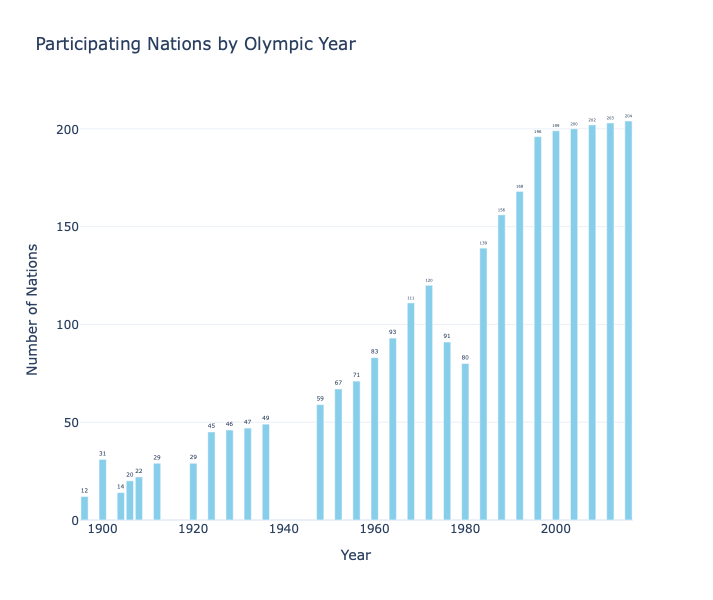

In [207]:
fig = px.bar(
    analysis,
    x='Year',
    y='column_name',
    title='Participating Nations by Olympic Year',
    labels={'column_name': 'Number of Nations'},
    text='column_name'          
)

fig.update_traces(marker_color='skyblue', textposition='outside')
fig.update_layout(template='plotly_white', height=600)
fig.show()

In [209]:
analysis2 = df.drop_duplicates(['Year','Name'])['Year'].value_counts().reset_index().sort_values('Year')

In [210]:
analysis2

,Year,count
28,1896,176
25,1900,1220
27,1904,650
26,1906,841
23,1908,2024
22,1912,2409
21,1920,2675
19,1924,3256
20,1928,3246
24,1932,1922


In [212]:
df.head(1)

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes,Bronze,Gold,Silver
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN,China,NaN,0,0,0


In [217]:

x = df.drop_duplicates(['Year', 'Sport', 'Event'])
pivot = x.pivot_table(index='Sport',columns='Year',values='Event',aggfunc='count').fillna(0).astype('int')

Text(0.5, 1.0, 'Number of Events by Sport and Year')

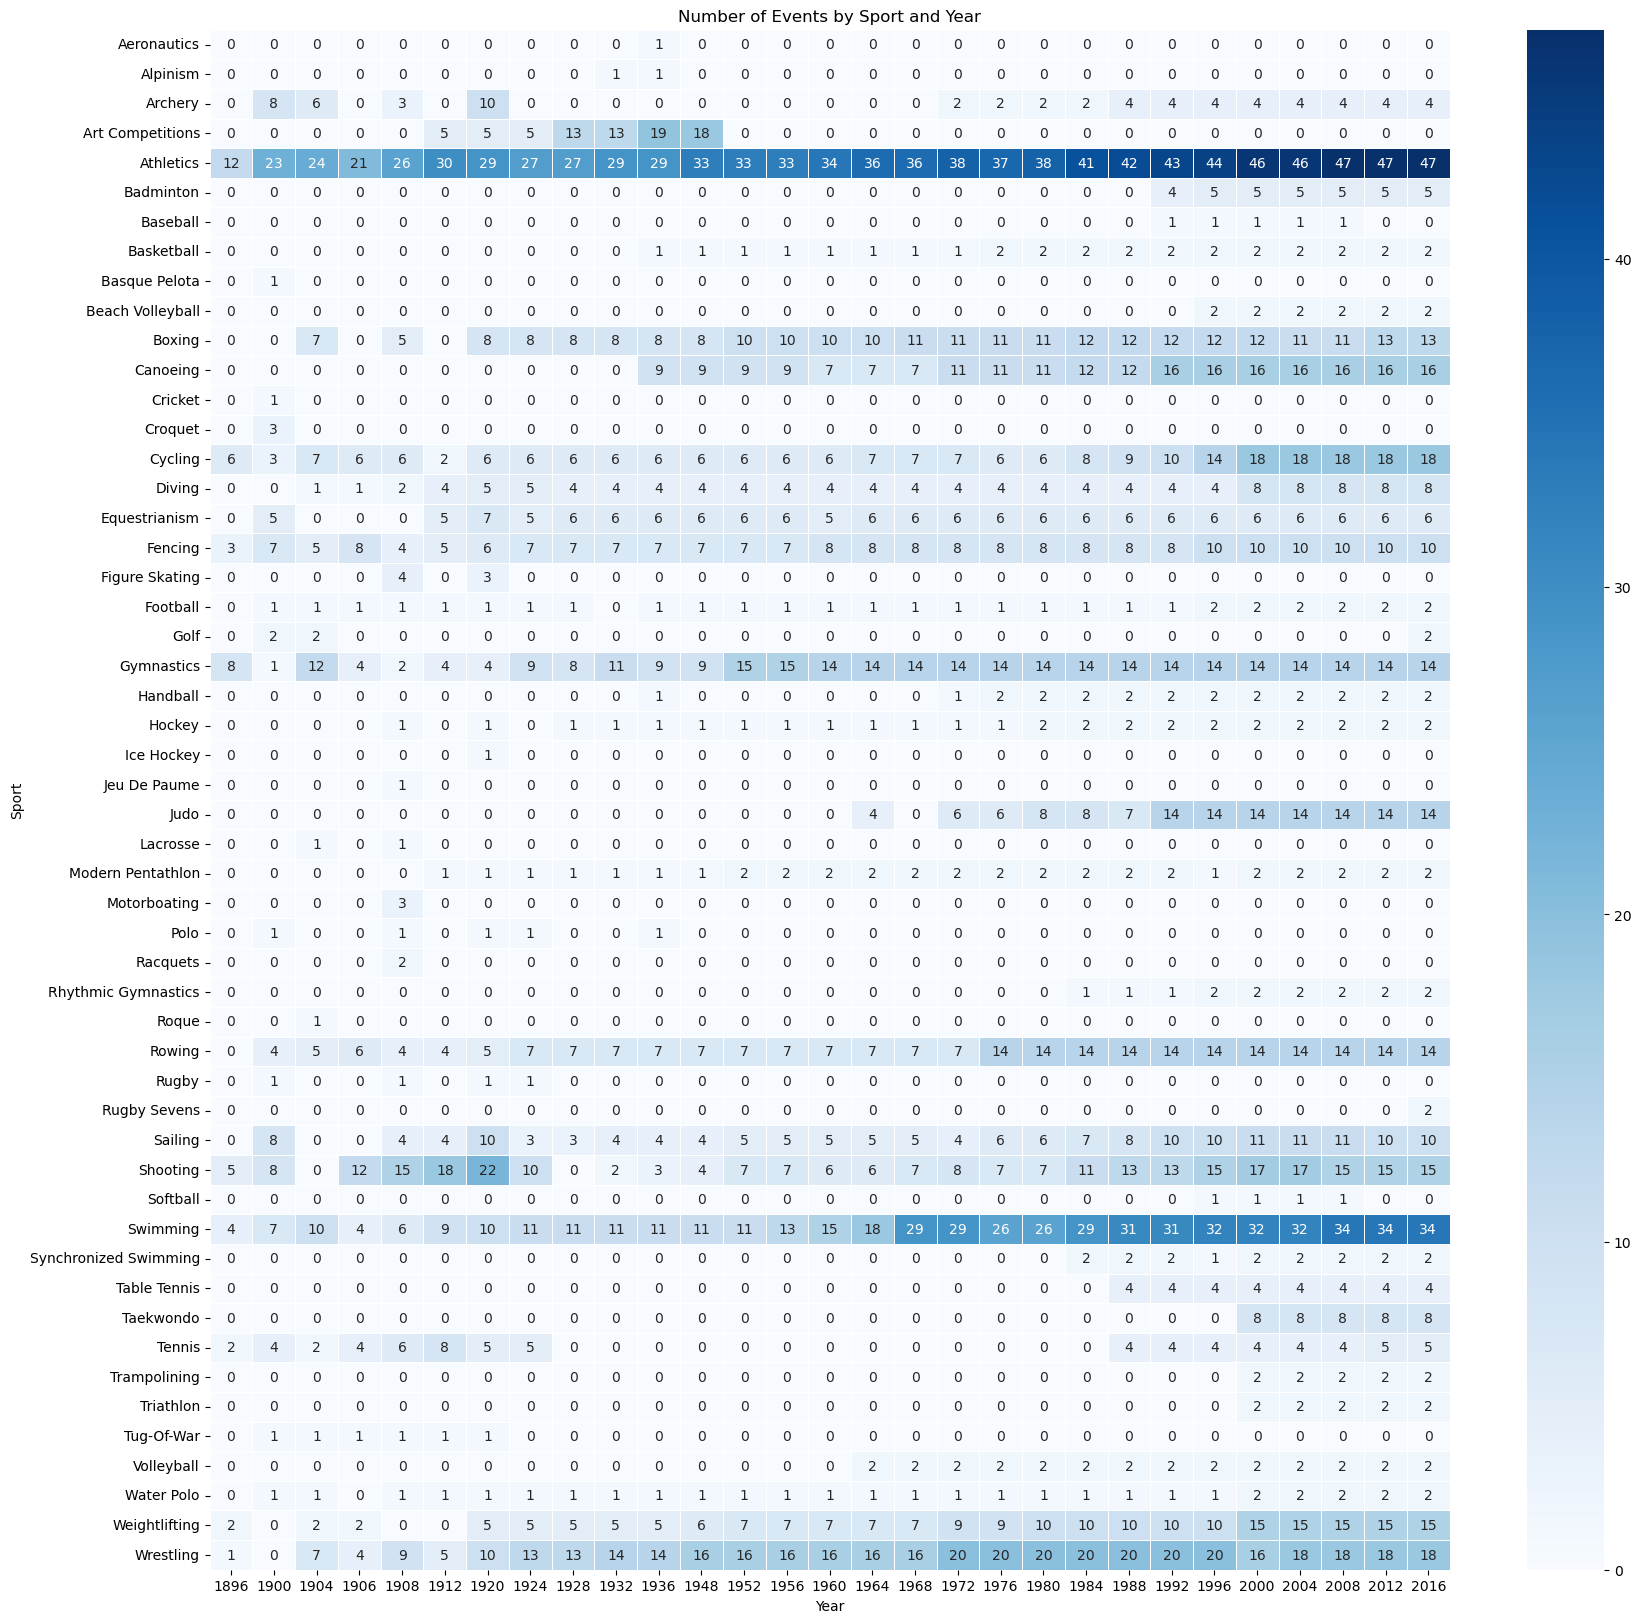

In [225]:
fig, ax = plt.subplots(figsize=(20, 20))  # Smaller than 20x20
sns.heatmap(pivot,annot=True,fmt="d",cmap="Blues",linewidths=0.5,ax=ax)
ax.set_title("Number of Events by Sport and Year")

In [266]:
def most_successful(df, sport):
    temp_df = df.dropna(subset=['Medal'])

    if sport != 'Overall':
        temp_df = temp_df[temp_df['Sport'] == sport]

    x = temp_df['Name'].value_counts().reset_index()
    x.columns = ['Name', 'Total']

    x = x.head(12).merge(
        df[['Name', 'Sport', 'region']].drop_duplicates('Name'),
        on='Name',
        how='left'
    )

    return x

In [267]:
most_successful(df,'Overall')

,Name,Total,Sport,region
0,"Michael Fred Phelps, II",28,Swimming,USA
1,Larysa Semenivna Latynina (Diriy-),18,Gymnastics,Russia
2,Nikolay Yefimovich Andrianov,15,Gymnastics,Russia
3,Borys Anfiyanovych Shakhlin,13,Gymnastics,Russia
4,Takashi Ono,13,Gymnastics,Japan
5,Edoardo Mangiarotti,13,Fencing,Italy
6,"Dara Grace Torres (-Hoffman, -Minas)",12,Swimming,USA
7,Aleksey Yuryevich Nemov,12,Gymnastics,Russia
8,"Jennifer Elisabeth ""Jenny"" Thompson (-Cumpelik)",12,Swimming,USA
9,Birgit Fischer-Schmidt,12,Canoeing,Germany


# Country wise analysis

In [292]:
temp_df =df.dropna(subset = ['Medal'])
temo_df = temp_df.drop_duplicates(subset = ['Team', 'region','NOC','Games', 'Season', 'City','Sport','Event','Medal'])
temp_df['Medal'] = pd.get_dummies(['Medal'])
temp_df['Total'] = temp_df['Bronze'] + temp_df['Silver'] + temp_df['Gold'] 
temp_df

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,...,City,Sport,Event,Medal,region,notes,Bronze,Gold,Silver,Total
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,...,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,NaN,Denmark,NaN,0,1,0,1
12,15,Arvo Ossian Aaltonen,M,30.0,NaN,NaN,Finland,FIN,1920 Summer,1920,...,Antwerpen,Swimming,Swimming Men's 200 metres Breaststroke,NaN,Finland,NaN,1,0,0,1
13,15,Arvo Ossian Aaltonen,M,30.0,NaN,NaN,Finland,FIN,1920 Summer,1920,...,Antwerpen,Swimming,Swimming Men's 400 metres Breaststroke,NaN,Finland,NaN,1,0,0,1
15,17,Paavo Johannes Aaltonen,M,28.0,175.0,64.0,Finland,FIN,1948 Summer,1948,...,London,Gymnastics,Gymnastics Men's Individual All-Around,NaN,Finland,NaN,1,0,0,1
16,17,Paavo Johannes Aaltonen,M,28.0,175.0,64.0,Finland,FIN,1948 Summer,1948,...,London,Gymnastics,Gymnastics Men's Team All-Around,NaN,Finland,NaN,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
222528,135553,Galina Ivanovna Zybina (-Fyodorova),F,25.0,168.0,80.0,Soviet Union,URS,1956 Summer,1956,...,Melbourne,Athletics,Athletics Women's Shot Put,NaN,Russia,NaN,0,0,1,1
222530,135553,Galina Ivanovna Zybina (-Fyodorova),F,33.0,168.0,80.0,Soviet Union,URS,1964 Summer,1964,...,Tokyo,Athletics,Athletics Women's Shot Put,NaN,Russia,NaN,1,0,0,1
222532,135554,Bogusaw Zych,M,28.0,182.0,82.0,Poland,POL,1980 Summer,1980,...,Moskva,Fencing,"Fencing Men's Foil, Team",NaN,Poland,NaN,1,0,0,1
222544,135563,Olesya Nikolayevna Zykina,F,19.0,171.0,64.0,Russia,RUS,2000 Summer,2000,...,Sydney,Athletics,Athletics Women's 4 x 400 metres Relay,NaN,Russia,NaN,1,0,0,1


In [293]:
new_df = temp_df[temp_df['region'] == 'Denmark']
final_df = new_df.groupby('Year')['Total'].sum()
final_df

Year
1896     6
1900     9
1906    34
1908    17
1912    87
1920    71
1924    14
1928    15
1932    11
1936     6
1948    51
1952     9
1956     6
1960    23
1964    12
1968    17
1972     1
1976     8
1980     8
1984    13
1988     7
1992    14
1996    23
2000    25
2004    29
2008    19
2012    16
2016    41
Name: Total, dtype: int64

In [297]:
temp_df = df.dropna(subset=['Medal'])
temp_df.drop_duplicates(subset=['Team', 'NOC', 'Games', 'Year', 'City', 'Sport', 'Event', 'Medal'], inplace=True)

new_df = temp_df[temp_df['region'] == 'Denmark']    
final_df = new_df.groupby('Year').count()['Medal'].reset_index()


<Axes: xlabel='Year', ylabel='Sport'>

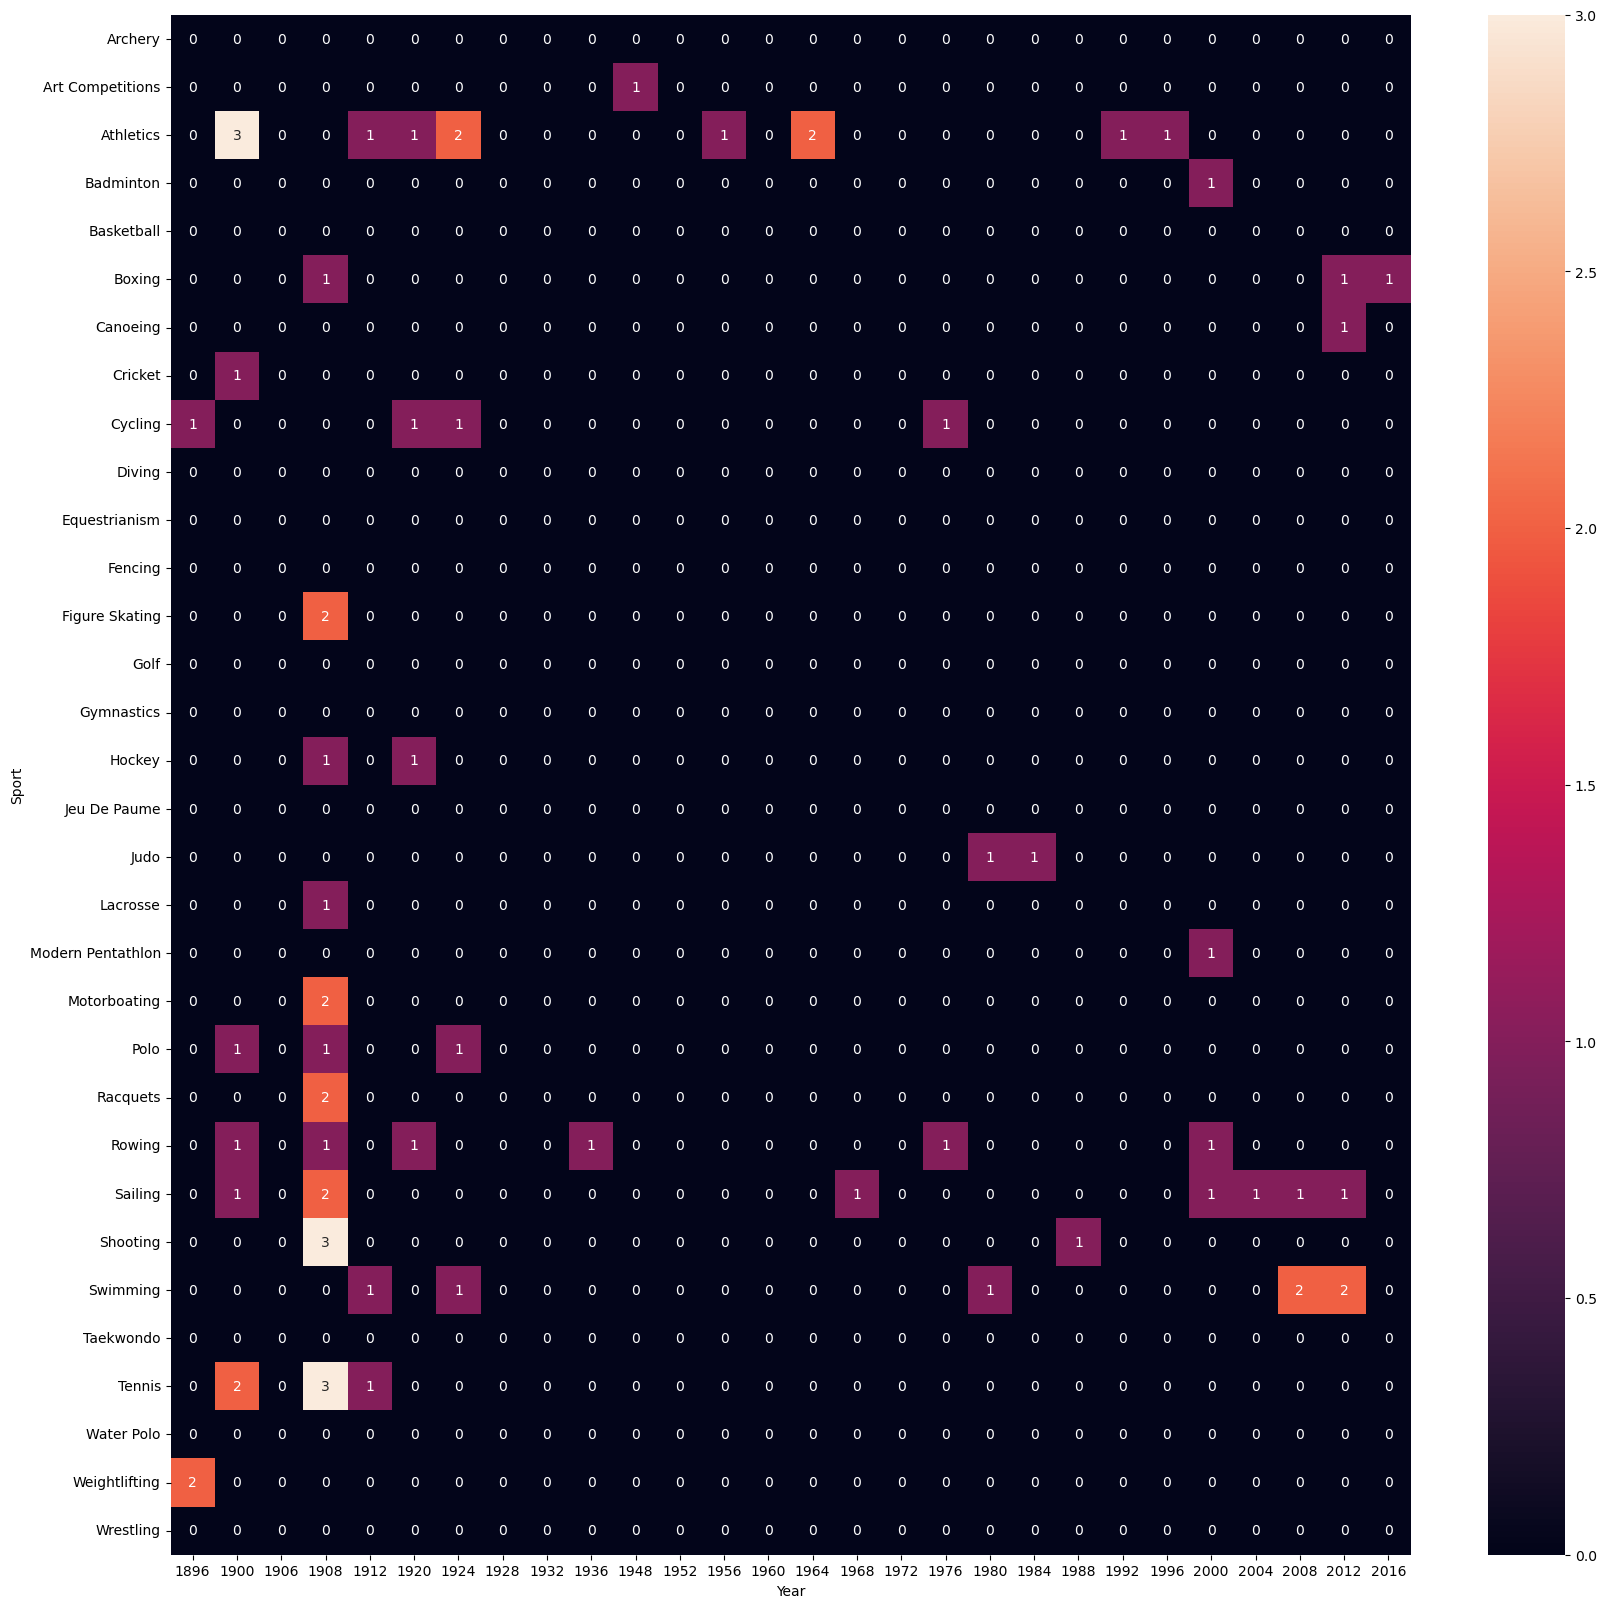

In [303]:
df = df.drop_duplicates(['Year', 'Sport', 'Event'])
df_new = df[df['region'] =='UK']
pivot = df_new.pivot_table(index='Sport',columns='Year',values='Medal',aggfunc='count').fillna(0).astype('int')
plt.figure(figsize=(20,20))
sns.heatmap(pivot , annot = True)

In [304]:
def most_successful_countrywise(df, sport):
    temp_df = df.dropna(subset=['Medal'])

    if sport != 'Overall':
        temp_df = temp_df[temp_df['Sport'] == sport]

    x = temp_df['Name'].value_counts().reset_index()
    x.columns = ['Name', 'Total']

    x = x.head(12).merge(
        df[['Name', 'Sport']].drop_duplicates('Name'),
        on='Name',
        how='left'
    )

    return x

In [305]:
most_successful_countrywise(df , sport = 'Swimming')

,Name,Total,Sport
0,"Rebecca ""Becky"" Adlington",4,Swimming
1,Nathan Ghar-Jun Adrian,3,Swimming
2,"Charles Meldrum ""Charlie"" Daniels",3,Swimming
3,"Christine M. ""Crissy"" Ahmann-Leighton (-Perham)",3,Swimming
4,Arvo Ossian Aaltonen,2,Swimming
5,Svetlana Viktorovna Babanina,2,Swimming
6,"Janice ""Jan"" Andrew (-Thornett)",2,Swimming
7,Malin Therse Alshammar,2,Swimming
8,"Robert Earl ""Bob"" Bennett",2,Swimming
9,Yannick Agnel,2,Swimming


# Model Making

In [433]:
df.shape

(221167, 17)

In [434]:
df['Medal'] = df['Medal'].fillna(0)
df.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,0,China,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,0,China,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,0,Denmark,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,Denmark,NaN
4,8,"Cornelia ""Cor"" Aalten (-Strannood)",F,18.0,168.0,NaN,Netherlands,NED,1932 Summer,1932,Summer,Los Angeles,Athletics,Athletics Women's 100 metres,0,Netherlands,NaN


In [435]:
df.columns

Index(['ID', 'Name', 'Sex', 'Age', 'Height', 'Weight', 'Team', 'NOC', 'Games',
       'Year', 'Season', 'City', 'Sport', 'Event', 'Medal', 'region', 'notes'],
      dtype='object')

In [436]:
new_df = df.drop(columns = ['ID','Name', 'Height', 'Weight' , 'City' , 'notes', 'Season' ,'NOC','Sex' , 'Event' , 'Games'] , axis = 1)

In [437]:
new_df.isnull().sum()

Age       9030
Team         0
Year         0
Sport        0
Medal        0
region     370
dtype: int64

In [438]:
new_df['Age'] = new_df['Age'].fillna(new_df['Age'].mean())

In [440]:
new_df.head()

,Age,Team,Year,Sport,Medal,region
0,24.0,China,1992,Basketball,0,China
1,23.0,China,2012,Judo,0,China
2,24.0,Denmark,1920,Football,0,Denmark
3,34.0,Denmark/Sweden,1900,Tug-Of-War,Gold,Denmark
4,18.0,Netherlands,1932,Athletics,0,Netherlands


In [453]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
new_df['Medal'] = new_df['Medal'].astype(str)
new_df['Medal'] = le.fit_transform(df['Medal'])
new_df['Medal'] = new_df['Medal'].astype(int)

In [454]:
new_df.head()

,Age,Team,Year,Sport,Medal,region
0,24.0,China,1992,Basketball,0,China
1,23.0,China,2012,Judo,0,China
2,24.0,Denmark,1920,Football,0,Denmark
3,34.0,Denmark/Sweden,1900,Tug-Of-War,2,Denmark
4,18.0,Netherlands,1932,Athletics,0,Netherlands
